# Image Decomposition and Bit-Plane Analysis (Bit-Plane Slicing)


This notebook analyzes the binary structure of pixels in 8-bit grayscale images using **bit-plane slicing** to quantify each bit's contribution to visual information.


The workflow has two stages:
1. **Bit-plane extraction:** Decompose the image into eight binary planes via bit shifts (`>>`) and masks (`&`). LSB planes carry mostly noise; MSB planes encode structure.
2. **Lossy reconstruction (quantization):** Rebuild the image from the most significant bits only. This mirrors lossy compression—showing how little data is needed for a readable result.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

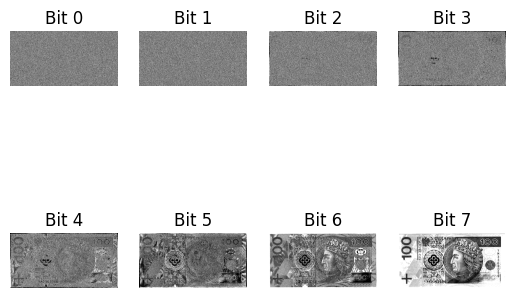

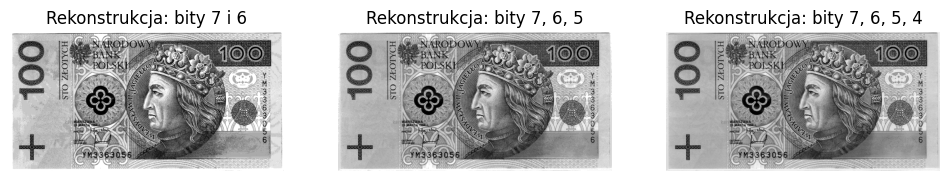

In [2]:
!wget -q https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/100zloty.jpg
banknot = cv2.imread('100zloty.jpg', cv2.IMREAD_GRAYSCALE)

bity = []

for i in range(8):
    warstwa = (banknot >> i) & 1
    bity.append(warstwa)

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(bity[i] * 255, cmap='gray')
    plt.title('Bit ' + str(i))
    plt.axis('off')
plt.show()

# Part II
plt.figure(figsize=(12, 4))
obraz_1 = (bity[7] << 7) + (bity[6] << 6)
obraz_2 = obraz_1 + (bity[5] << 5)
obraz_3 = obraz_2 + (bity[4] << 4)

plt.subplot(1, 3, 1)
plt.imshow(obraz_1, cmap='gray')
plt.title('Reconstruction: bits 7 and 6')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(obraz_2, cmap='gray')
plt.title('Reconstruction: bits 7, 6, 5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(obraz_3, cmap='gray')
plt.title('Reconstruction: bits 7, 6, 5, 4')
plt.axis('off')

plt.show()